**Explore the dataset with this notebook**  

The dataset is too large for github. In this notebook, I assume the dataset file is located in the same directory.  



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## Explore the Data and Data Cleaning

In [2]:
# These commands below set some options for pandas and to have matplotlib show the charts in the notebook
pd.set_option('display.max_rows', 1000)
pd.set_option("display.max_columns", 28)
pd.options.display.float_format = '{:,.2f}'.format

# Load the data, set index to 0 (DR_NO) and parse DateTime columns
crime_df = pd.read_csv('Crime_Data_from_2020_to_Present.csv', index_col=0) 


In [3]:
## Make the Date OCC and Time OCC one complete timestamp

##convert time int objects to strings with 4 digits
time = crime_df["TIME OCC"].astype(str).str.zfill(4)

#convert to datetime to get rid of the 1200 AM/PM and convert back to string
date = pd.to_datetime(crime_df["DATE OCC"]).astype(str)

#concatenate and create a new column 
date_col = date + " " + time

#save the new column in the original DATE OCC column
crime_df["DATE OCC"] = pd.to_datetime(date_col, format="%Y-%m-%d %H%M", exact = True)


#now we can drop the TIME OCC column since it is correctly represented in the DATE OCC-- Will do later



/var/folders/7y/pry034n17xs1w4n0rfm69zh00000gn/T/ipykernel_57661/2886710103.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date = pd.to_datetime(crime_df["DATE OCC"]).astype(str)


### Column header full name:
- Date Rptd: Date Reported
- DATE OCC: Date Occurred
- TIME OCC: Time Occurred
- AREA: Area Code (often a numerical identifier for a police reporting area)
- AREA NAME: Area Name (the textual name associated with the Area Code)
- Rpt Dist No: Reporting District Number (a smaller geographical subdivision within an Area)
- Part 1-2: Part 1 and Part 2 Crimes (referring to the FBI's Uniform Crime Reporting (UCR) Program crime classifications. Part 1 are more serious offenses.)
- Crm Cd: Crime Code (a numerical code identifying the specific type of crime)
- Crm Cd Desc: Crime Code Description (the textual description of the Crime Code)
- Mocodes: Modus Operandi Codes (codes describing the method of operation used by the suspect(s))
- Vict Age: Victim Age
- Vict Sex: Victim Sex
- Vict Descent: Victim Descent (referring to the victim's race or ethnicity)
- Premis Cd: Premise Code (a numerical code identifying the type of location where the crime occurred)
- Premis Desc: Premise Description (the textual description of the Premise Code)
- Weapon Used Cd: Weapon Used Code (a numerical code identifying the type of weapon used, if any)
- Weapon Desc: Weapon Description (the textual description of the Weapon Used Code)
- Status: Case Status Code (a code indicating the current status of the police investigation)
- Status Desc: Case Status Description (the textual description of the Case Status Code)
- Crm Cd 1: Crime Code 1 (the primary crime committed in the incident)
- Crm Cd 2: Crime Code 2 (a secondary crime committed in the incident, if any)
- Crm Cd 3: Crime Code 3 (a tertiary crime committed in the incident, if any)
- Crm Cd 4: Crime Code 4 (a quaternary crime committed in the incident, if any)
- LOCATION: Location (often a street address or general area description)
- Cross Street: Cross Street (the nearest intersecting street to the location of the crime)
- LAT: Latitude (the geographical coordinate)
- LON: Longitude (the geographical coordinate)

In [4]:
#make sure the df looks right
crime_df.head(10)

,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
DR_NO,,,,,,,,,,,,,,,,,,,,,,,,,,,
190326475,03/01/2020 12:00:00 AM,2020-03-01 21:30:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,NaN,0,M,O,101.00,STREET,NaN,NaN,AA,Adult Arrest,510.00,998.00,NaN,NaN,1900 S LONGWOOD AV,NaN,34.04,-118.35
200106753,02/09/2020 12:00:00 AM,2020-02-08 18:00:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,1822 1402 0344,47,M,O,128.00,BUS STOP/LAYOVER (ALSO QUERY 124),NaN,NaN,IC,Invest Cont,330.00,998.00,NaN,NaN,1000 S FLOWER ST,NaN,34.04,-118.26
200320258,11/11/2020 12:00:00 AM,2020-11-04 17:00:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,0344 1251,19,X,X,502.00,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",NaN,NaN,IC,Invest Cont,480.00,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.02,-118.30
200907217,05/10/2023 12:00:00 AM,2020-03-10 20:37:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),0325 1501,19,M,O,405.00,CLOTHING STORE,NaN,NaN,IC,Invest Cont,343.00,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.16,-118.44
200412582,09/09/2020 12:00:00 AM,2020-09-09 06:30:00,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,NaN,0,NaN,NaN,101.00,STREET,NaN,NaN,IC,Invest Cont,510.00,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.08,-118.21
200209713,05/03/2020 12:00:00 AM,2020-05-02 18:00:00,1800,2,Rampart,245,1,510,VEHICLE - STOLEN,NaN,0,NaN,NaN,101.00,STREET,NaN,NaN,IC,Invest Cont,510.00,NaN,NaN,NaN,2500 W 4TH ST,NaN,34.06,-118.28
200200759,07/07/2020 12:00:00 AM,2020-07-07 13:40:00,1340,2,Rampart,265,1,648,ARSON,0329 1402 2004 1501,0,X,X,101.00,STREET,NaN,NaN,IC,Invest Cont,648.00,998.00,NaN,NaN,JAMES M WOOD,ALVARADO,34.05,-118.28
201308739,03/27/2020 12:00:00 AM,2020-03-27 12:10:00,1210,13,Newton,1333,1,510,VEHICLE - STOLEN,NaN,0,NaN,NaN,101.00,STREET,NaN,NaN,IC,Invest Cont,510.00,NaN,NaN,NaN,3200 S SAN PEDRO ST,NaN,34.02,-118.26
201112065,07/31/2020 12:00:00 AM,2020-07-30 20:30:00,2030,11,Northeast,1161,1,510,VEHICLE - STOLEN,NaN,0,NaN,NaN,101.00,STREET,NaN,NaN,AA,Adult Arrest,510.00,NaN,NaN,NaN,KENMORE ST,FOUNTAIN,34.10,-118.30


In [5]:
#view the columns
crime_df.columns

Index(['Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME', 'Rpt Dist No',
       'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes', 'Vict Age', 'Vict Sex',
       'Vict Descent', 'Premis Cd', 'Premis Desc', 'Weapon Used Cd',
       'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1', 'Crm Cd 2',
       'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT', 'LON'],
      dtype='object')

In [6]:
crime_df.shape #get df shape

(1005149, 27)

There are 28 columns and just over 1 million rows. This matches the dataset description

In [7]:
crime_df.count() #check to see the number of filled entries

Date Rptd         1005149
DATE OCC          1005149
TIME OCC          1005149
AREA              1005149
AREA NAME         1005149
Rpt Dist No       1005149
Part 1-2          1005149
Crm Cd            1005149
Crm Cd Desc       1005149
Mocodes            853408
Vict Age          1005149
Vict Sex           860384
Vict Descent       860372
Premis Cd         1005133
Premis Desc       1004561
Weapon Used Cd     327264
Weapon Desc        327264
Status            1005148
Status Desc       1005149
Crm Cd 1          1005138
Crm Cd 2            69153
Crm Cd 3             2314
Crm Cd 4               64
LOCATION          1005149
Cross Street       154240
LAT               1005149
LON               1005149
dtype: int64

In [8]:
crime_df.isna().sum() #find the number of nans

Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151741
Vict Age                0
Vict Sex           144765
Vict Descent       144777
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677885
Weapon Desc        677885
Status                  1
Status Desc             0
Crm Cd 1               11
Crm Cd 2           935996
Crm Cd 3          1002835
Crm Cd 4          1005085
LOCATION                0
Cross Street       850909
LAT                     0
LON                     0
dtype: int64

In [9]:
crime_df.dtypes #check dtypes

Date Rptd                 object
DATE OCC          datetime64[ns]
TIME OCC                   int64
AREA                       int64
AREA NAME                 object
Rpt Dist No                int64
Part 1-2                   int64
Crm Cd                     int64
Crm Cd Desc               object
Mocodes                   object
Vict Age                   int64
Vict Sex                  object
Vict Descent              object
Premis Cd                float64
Premis Desc               object
Weapon Used Cd           float64
Weapon Desc               object
Status                    object
Status Desc               object
Crm Cd 1                 float64
Crm Cd 2                 float64
Crm Cd 3                 float64
Crm Cd 4                 float64
LOCATION                  object
Cross Street              object
LAT                      float64
LON                      float64
dtype: object

In [10]:
#Clean the column names to allow dot notation
#simplifiy working with the dataset
columns = crime_df.columns
new_cols = []
for col in columns:
    col = col.strip()
    col = col.replace(" ", "_")
    col = col.lower()
    new_cols.append(col)

crime_df.columns = new_cols

display(crime_df)

,date_rptd,date_occ,time_occ,area,area_name,rpt_dist_no,part_1-2,crm_cd,crm_cd_desc,mocodes,vict_age,vict_sex,vict_descent,premis_cd,premis_desc,weapon_used_cd,weapon_desc,status,status_desc,crm_cd_1,crm_cd_2,crm_cd_3,crm_cd_4,location,cross_street,lat,lon
DR_NO,,,,,,,,,,,,,,,,,,,,,,,,,,,
190326475,03/01/2020 12:00:00 AM,2020-03-01 21:30:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,NaN,0,M,O,101.00,STREET,NaN,NaN,AA,Adult Arrest,510.00,998.00,NaN,NaN,1900 S LONGWOOD AV,NaN,34.04,-118.35
200106753,02/09/2020 12:00:00 AM,2020-02-08 18:00:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,1822 1402 0344,47,M,O,128.00,BUS STOP/LAYOVER (ALSO QUERY 124),NaN,NaN,IC,Invest Cont,330.00,998.00,NaN,NaN,1000 S FLOWER ST,NaN,34.04,-118.26
200320258,11/11/2020 12:00:00 AM,2020-11-04 17:00:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,0344 1251,19,X,X,502.00,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",NaN,NaN,IC,Invest Cont,480.00,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.02,-118.30
200907217,05/10/2023 12:00:00 AM,2020-03-10 20:37:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),0325 1501,19,M,O,405.00,CLOTHING STORE,NaN,NaN,IC,Invest Cont,343.00,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.16,-118.44
200412582,09/09/2020 12:00:00 AM,2020-09-09 06:30:00,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,NaN,0,NaN,NaN,101.00,STREET,NaN,NaN,IC,Invest Cont,510.00,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.08,-118.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252104053,01/19/2025 12:00:00 AM,2025-01-17 15:30:00,1530,21,Topanga,2114,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",0344,0,M,W,720.00,JUNIOR HIGH SCHOOL,NaN,NaN,IC,Invest Cont,341.00,NaN,NaN,NaN,22200 ELKWOOD ST,NaN,34.21,-118.61
250304214,02/23/2025 12:00:00 AM,2025-02-21 15:30:00,1530,3,Southwest,358,1,510,VEHICLE - STOLEN,NaN,0,NaN,NaN,101.00,STREET,NaN,NaN,IC,Invest Cont,510.00,NaN,NaN,NaN,3600 MCCLINTOCK AV,NaN,34.02,-118.29
250304203,02/20/2025 12:00:00 AM,2025-02-13 21:00:00,2100,3,Southwest,325,1,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",NaN,0,NaN,NaN,108.00,PARKING LOT,NaN,NaN,IC,Invest Cont,522.00,NaN,NaN,NaN,2600 ELLENDALE PL,NaN,34.03,-118.29


In [11]:
#inspect duplicates
crime_df[crime_df.duplicated(keep=False)]

,date_rptd,date_occ,time_occ,area,area_name,rpt_dist_no,part_1-2,crm_cd,crm_cd_desc,mocodes,vict_age,vict_sex,vict_descent,premis_cd,premis_desc,weapon_used_cd,weapon_desc,status,status_desc,crm_cd_1,crm_cd_2,crm_cd_3,crm_cd_4,location,cross_street,lat,lon
DR_NO,,,,,,,,,,,,,,,,,,,,,,,,,,,
200208642,04/06/2020 12:00:00 AM,2020-04-06 00:01:00,1,2,Rampart,217,1,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",NaN,0,NaN,NaN,121.00,YARD (RESIDENTIAL/BUSINESS),NaN,NaN,IC,Invest Cont,522.00,NaN,NaN,NaN,1700 CLINTON ST,NaN,34.07,-118.26
201115225,10/29/2020 12:00:00 AM,2020-10-29 05:30:00,530,11,Northeast,1177,1,510,VEHICLE - STOLEN,NaN,0,NaN,NaN,108.00,PARKING LOT,NaN,NaN,IC,Invest Cont,510.00,NaN,NaN,NaN,2200 N FIGUEROA ST,NaN,34.09,-118.23
200517938,12/18/2020 12:00:00 AM,2020-12-18 03:42:00,342,5,Harbor,501,1,310,BURGLARY,0344 0358 1402 1602 0397,0,X,X,221.00,PUBLIC STORAGE,NaN,NaN,IC,Invest Cont,310.00,NaN,NaN,NaN,600 W 184TH ST,NaN,33.87,-118.28
200411060,07/22/2020 12:00:00 AM,2020-07-22 22:10:00,2210,4,Hollenbeck,497,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329 1300,0,X,X,511.00,PROJECT/TENEMENT/PUBLIC HOUSING,NaN,NaN,IC,Invest Cont,740.00,NaN,NaN,NaN,OLYMPIC,LORENA,34.02,-118.21
200317171,09/12/2020 12:00:00 AM,2020-09-11 19:00:00,1900,3,Southwest,353,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),NaN,0,NaN,NaN,108.00,PARKING LOT,NaN,NaN,IC,Invest Cont,420.00,NaN,NaN,NaN,3700 CRENSHAW BL,NaN,34.02,-118.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250504146,02/10/2025 12:00:00 AM,2025-02-05 14:30:00,1430,5,Harbor,523,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",NaN,0,NaN,NaN,101.00,STREET,NaN,NaN,IC,Invest Cont,341.00,NaN,NaN,NaN,2000 JOHN S GIBSON BL,NaN,33.76,-118.29
250504143,02/10/2025 12:00:00 AM,2025-02-05 19:30:00,1930,5,Harbor,523,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",NaN,0,NaN,NaN,101.00,STREET,NaN,NaN,IC,Invest Cont,341.00,NaN,NaN,NaN,2000 JOHN S GIBSON BL,NaN,33.76,-118.29
250504144,02/10/2025 12:00:00 AM,2025-02-05 19:30:00,1930,5,Harbor,523,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",NaN,0,NaN,NaN,101.00,STREET,NaN,NaN,IC,Invest Cont,341.00,NaN,NaN,NaN,2000 JOHN S GIBSON BL,NaN,33.76,-118.29


In [12]:
#check how many duplicates
dupes = crime_df[crime_df.duplicated()]
dupe_count = len(dupes)
df_count = len(crime_df)

print("Number of Duplicates: ", dupe_count)
print("Length of DF: ", df_count)


Number of Duplicates:  2978
Length of DF:  1005149


In [13]:
crime_df = crime_df.drop_duplicates()
assert len(crime_df) == (df_count - dupe_count)


In [14]:
len(crime_df[crime_df['vict_age'] < 0]) #find the number of victims whose age is less than 0

133

In [15]:
crime_df[crime_df['vict_age'] < 0] #show these crimes

,date_rptd,date_occ,time_occ,area,area_name,rpt_dist_no,part_1-2,crm_cd,crm_cd_desc,mocodes,vict_age,vict_sex,vict_descent,premis_cd,premis_desc,weapon_used_cd,weapon_desc,status,status_desc,crm_cd_1,crm_cd_2,crm_cd_3,crm_cd_4,location,cross_street,lat,lon
DR_NO,,,,,,,,,,,,,,,,,,,,,,,,,,,
240106626,12/31/2020 12:00:00 AM,2020-01-01 12:00:00,1200,1,Central,112,2,662,"BUNCO, GRAND THEFT",0701 0800 0100 1822,-4,X,X,203.00,OTHER BUSINESS,NaN,NaN,AA,Adult Arrest,662.00,NaN,NaN,NaN,300 N SPRING ST,NaN,34.05,-118.24
242104815,01/20/2024 12:00:00 AM,2020-12-12 11:07:00,1107,21,Topanga,2189,1,442,SHOPLIFTING - PETTY THEFT ($950 & UNDER),2028 0325,-3,M,W,404.00,DEPARTMENT STORE,NaN,NaN,AA,Adult Arrest,442.00,NaN,NaN,NaN,20800 VENTURA BL,NaN,34.17,-118.59
231806653,06/12/2022 12:00:00 AM,2020-03-04 08:00:00,800,18,Southeast,1832,2,946,OTHER MISCELLANEOUS CRIME,0913 0935,-2,X,X,726.00,POLICE FACILITY,NaN,NaN,IC,Invest Cont,946.00,NaN,NaN,NaN,100 W 108TH ST,NaN,33.94,-118.28
240608551,04/17/2024 12:00:00 AM,2020-08-01 13:00:00,1300,6,Hollywood,656,2,354,THEFT OF IDENTITY,1822 0928,-3,X,X,502.00,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",NaN,NaN,IC,Invest Cont,354.00,NaN,NaN,NaN,900 VINE ST,NaN,34.09,-118.33
230610629,06/02/2023 12:00:00 AM,2020-05-31 04:30:00,430,6,Hollywood,645,1,310,BURGLARY,1822 1607 0216 0344 1402,-2,X,X,203.00,OTHER BUSINESS,500.00,UNKNOWN WEAPON/OTHER WEAPON,AA,Adult Arrest,310.00,998.00,NaN,NaN,1700 ORCHID AV,NaN,34.10,-118.34
232112493,08/04/2023 12:00:00 AM,2020-07-08 15:53:00,1553,21,Topanga,2103,1,442,SHOPLIFTING - PETTY THEFT ($950 & UNDER),0325 2028,-2,M,W,234.00,OPTICAL OFFICE INSIDE STORE OR SUPERMARKET*,NaN,NaN,AA,Adult Arrest,442.00,NaN,NaN,NaN,8300 TOPANGA CANYON BL,NaN,34.23,-118.61
242010085,07/05/2024 12:00:00 AM,2020-03-05 17:00:00,1700,20,Olympic,2029,1,440,THEFT PLAIN - PETTY ($950 & UNDER),1822 0344,-3,X,X,725.00,"GOVERNMENT FACILITY (FEDERAL,STATE, COUNTY & C...",NaN,NaN,IC,Invest Cont,440.00,NaN,NaN,NaN,500 S VERMONT AV,NaN,34.07,-118.29
231412171,06/09/2023 12:00:00 AM,2020-06-01 12:00:00,1200,14,Pacific,1435,2,930,CRIMINAL THREATS - NO WEAPON DISPLAYED,0443,-2,M,W,501.00,SINGLE FAMILY DWELLING,511.00,VERBAL THREAT,IC,Invest Cont,930.00,NaN,NaN,NaN,3500 GRAND VIEW BL,NaN,34.01,-118.44
211008197,05/19/2021 12:00:00 AM,2020-01-01 12:00:00,1200,10,West Valley,1094,1,310,BURGLARY,0389 1822 0344 1609 0321,-1,M,O,501.00,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,310.00,NaN,NaN,NaN,4100 GREENBRIAR LN,NaN,34.15,-118.53


### Remove the age that doen't make sense

In [16]:
crime_df_cleaned = crime_df[crime_df['vict_age'] >= 0].copy()
print(f"Number of rows with 'vict_age' less than 0 in the cleaned DataFrame: {len(crime_df_cleaned[crime_df_cleaned['vict_age'] < 0])}")


Number of rows with 'vict_age' less than 0 in the cleaned DataFrame: 0


## Data Analysis- Phase 1

In [17]:
crime_df_cleaned.value_counts(['vict_sex'])


vict_sex
M           403145
F           358332
X            96906
H              114
-                1
Name: count, dtype: int64

In [18]:
crime_df_cleaned.describe()

,date_occ,time_occ,area,rpt_dist_no,part_1-2,crm_cd,vict_age,premis_cd,weapon_used_cd,crm_cd_1,crm_cd_2,crm_cd_3,crm_cd_4,lat,lon
count,1002038,"1,002,038.00","1,002,038.00","1,002,038.00","1,002,038.00","1,002,038.00","1,002,038.00","1,002,022.00","326,305.00","1,002,027.00","69,074.00","2,312.00",64.00,"1,002,038.00","1,002,038.00"
mean,2022-05-14 06:42:11.805779712,"1,340.03",10.69,"1,115.67",1.40,500.05,28.99,305.68,364.02,499.81,958.13,984.00,991.22,34.00,-118.09
min,2020-01-01 00:01:00,1.00,1.00,101.00,1.00,110.00,0.00,101.00,101.00,110.00,210.00,310.00,821.00,0.00,-118.67
25%,2021-04-06 12:40:00,900.00,5.00,587.00,1.00,331.00,0.00,101.00,311.00,331.00,998.00,998.00,998.00,34.01,-118.43
50%,2022-05-26 11:05:00,"1,420.00",11.00,"1,139.00",1.00,442.00,30.00,203.00,400.00,442.00,998.00,998.00,998.00,34.06,-118.32
75%,2023-06-22 04:04:00,"1,900.00",16.00,"1,613.00",2.00,626.00,44.00,501.00,400.00,626.00,998.00,998.00,998.00,34.16,-118.27
max,2025-03-13 17:57:00,"2,359.00",21.00,"2,199.00",2.00,956.00,120.00,976.00,516.00,956.00,999.00,999.00,999.00,34.33,0.00
std,NaN,650.94,6.11,611.14,0.49,205.28,21.98,219.14,123.66,205.08,110.35,52.37,27.07,1.61,5.59


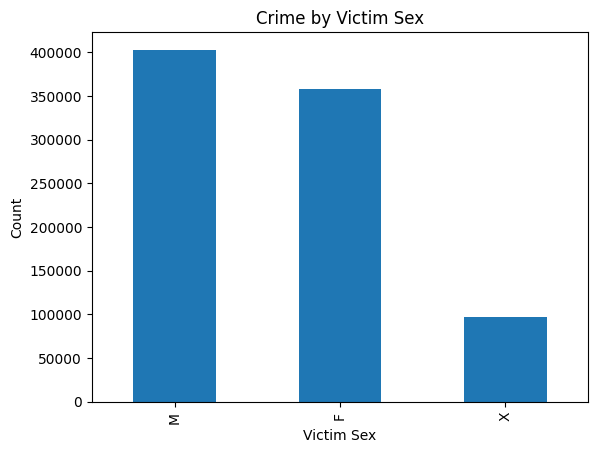

In [19]:
crime_df_cleaned['vict_sex'].value_counts().iloc[:3].plot(kind='bar')
plt.title('Crime by Victim Sex')
plt.xlabel('Victim Sex')
plt.ylabel('Count')
plt.show()



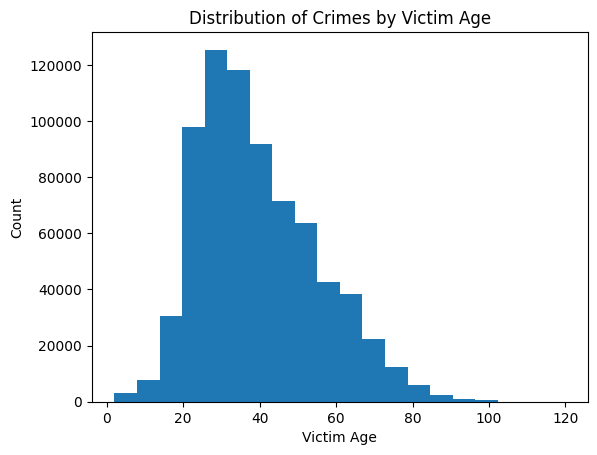

In [20]:
crime_df_cleaned[crime_df_cleaned['vict_age'] > 0]['vict_age'].plot(kind='hist', bins=20)
plt.title('Distribution of Crimes by Victim Age')
plt.xlabel('Victim Age')
plt.ylabel('Count')
plt.show()


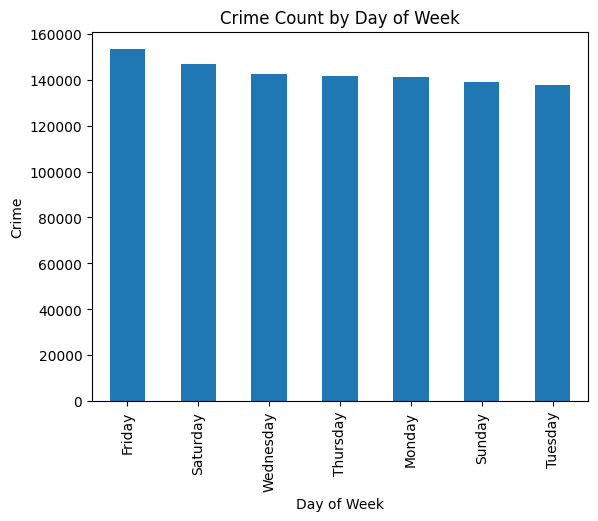

In [21]:
dates = crime_df_cleaned['date_occ']
dates = pd.DatetimeIndex(dates)
dates = dates.day_name()
dates.value_counts().plot(kind="bar")
plt.title('Crime Count by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Crime')
plt.show()

<Axes: xlabel='date_occ'>

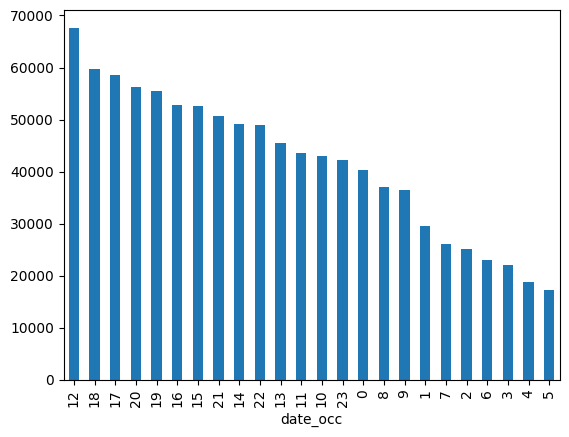

In [22]:
crime_df_cleaned["date_occ"].dt.hour.value_counts().plot(kind='bar')


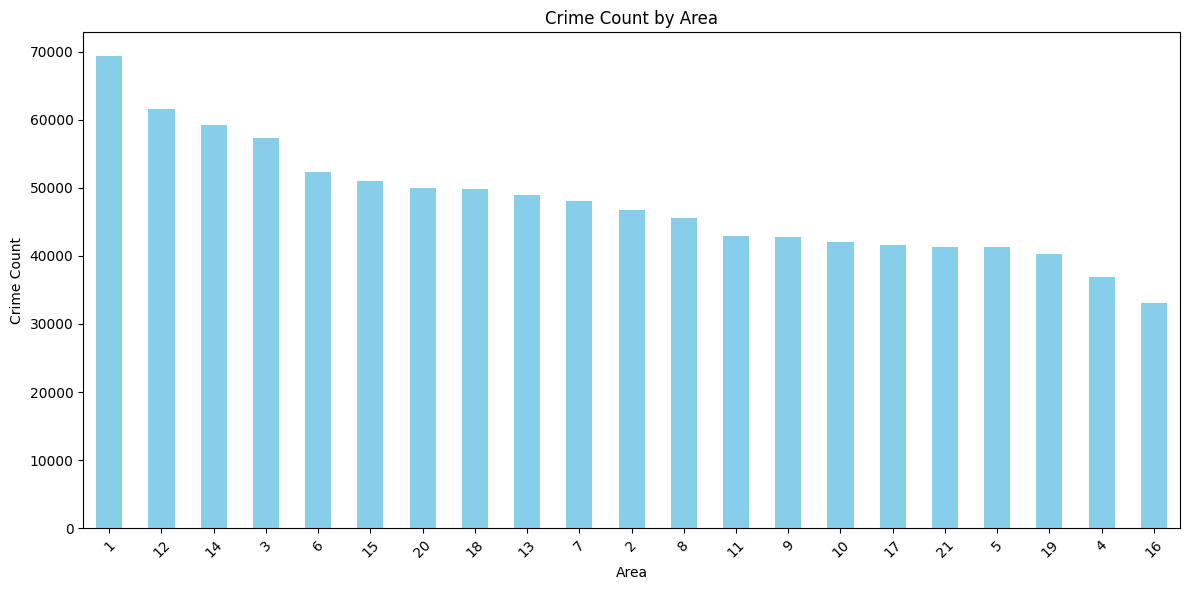

In [23]:
# Crime Count by Area/Location

crime_area_count = crime_df_cleaned['area'].value_counts()

# Plot
crime_area_count.plot(kind='bar', figsize=(12, 6), color='skyblue')
plt.title('Crime Count by Area')
plt.xlabel('Area')
plt.ylabel('Crime Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/7y/pry034n17xs1w4n0rfm69zh00000gn/T/ipykernel_57661/2198753691.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


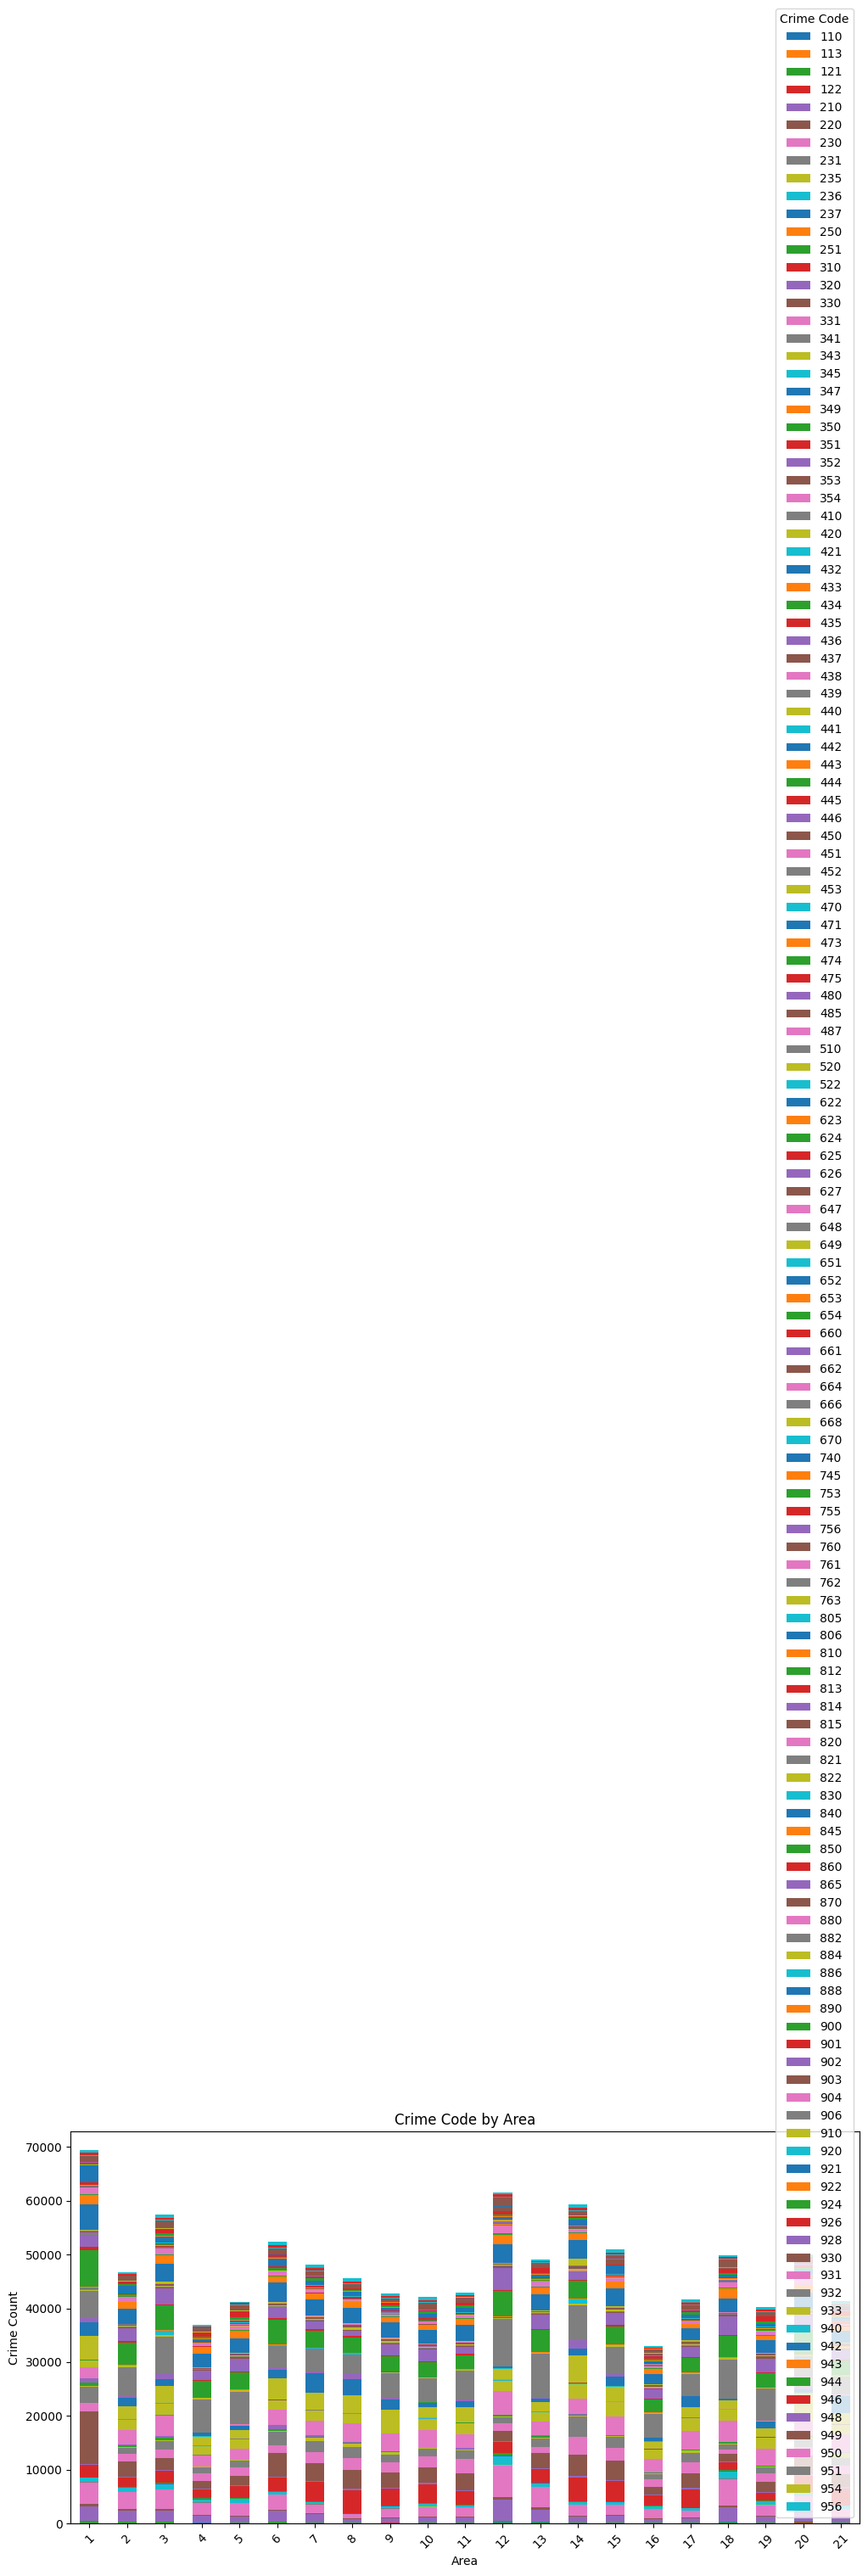

In [24]:
# Crime Code by Area
crime_code_by_area = crime_df_cleaned.groupby(['area', 'crm_cd']).size().unstack().fillna(0)

# Plot
crime_code_by_area.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Crime Code by Area')
plt.xlabel('Area')
plt.ylabel('Crime Count')
plt.xticks(rotation=45)
plt.legend(title='Crime Code')
plt.tight_layout()
plt.show()


## Data Analysis - Phase 2

### Analysis for COVID Impact with Crime Count by Area:

**1. Temporal Trends in Crime Counts by Area:**

* **Analysis:** Calculate total and specific crime counts per `area` for pre-COVID (before March 2021), during COVID (March 2021 - May 2023), and post-COVID (after May 2023) periods.
* **Value for COVID Analysis:** Examining the raw number of crimes can reveal the absolute impact of the pandemic on criminal activity levels in different areas.
* **Potential Insights:** Identify areas that experienced the most significant increases or decreases in overall and specific crime counts during and after the pandemic. Determine if crime counts have returned to pre-pandemic levels or established new baselines in different neighborhoods of the district.

**2. Shifts in Dominant Crime Types by Area (Based on Count):**

* **Analysis:** Identify the most frequent `crm_cd` in each `area` for the pre-COVID, during COVID, and post-COVID periods based on the number of occurrences. Analyze how the proportion of these crime types within each area changed across the three timelines.
* **Value for COVID Analysis:** Comparing the counts of different crime types highlights shifts in the types of criminal activity that were most prevalent in each area due to the pandemic.
* **Potential Insights:** Determine if the pandemic led to a change in the dominant types of crime experienced in different areas (e.g., an increase in certain property crimes during economic hardship or changes in public order offenses during lockdowns).

**3. Changes in Victim Demographics by Area (Based on Count):**

* **Analysis:** For each `area` and the pre-COVID, during COVID, and post-COVID periods, analyze the counts of victims based on `vict_age`, `vict_sex`, and `vict_descent`. Observe how the distribution of these demographics changed over time within each area for specific crime types.
* **Value for COVID Analysis:** Understanding changes in the number of victims from different demographic groups in various areas during the pandemic can point to specific populations that may have been disproportionately affected.
* **Potential Insights:** Identify if the pandemic led to a notable increase or decrease in the number of victims from certain demographic groups in specific areas for particular types of crimes.

**Key Considerations for Analyzing Crime Counts:**

* **Focus on Absolute Numbers:** The analysis will focus on the absolute number of reported crimes and changes in those numbers over time within LA

### Data Cleaning

In [25]:
# convert date_occ to date
crime_df_cleaned['date_occ'] = crime_df_cleaned['date_occ'].dt.date

#convert time_occ to time format
def format_time(time_int):
    '''convert to time format'''
    time_str = str(time_int).zfill(4)  # add zero if needed(e.g., 0800)
    hours = time_str[:2]
    minutes = time_str[2:]
    return f"{hours}:{minutes}:00" 

crime_df_cleaned['time_occ'] = crime_df_cleaned['time_occ'].astype(str).apply(format_time)

crime_df_cleaned['time_occ'] = pd.to_datetime(crime_df_cleaned['time_occ'], format='%H:%M:%S').dt.time

crime_df_cleaned.head(2)


,date_rptd,date_occ,time_occ,area,area_name,rpt_dist_no,part_1-2,crm_cd,crm_cd_desc,mocodes,vict_age,vict_sex,vict_descent,premis_cd,premis_desc,weapon_used_cd,weapon_desc,status,status_desc,crm_cd_1,crm_cd_2,crm_cd_3,crm_cd_4,location,cross_street,lat,lon
DR_NO,,,,,,,,,,,,,,,,,,,,,,,,,,,
190326475,03/01/2020 12:00:00 AM,2020-03-01,21:30:00,7,Wilshire,784,1,510,VEHICLE - STOLEN,NaN,0,M,O,101.00,STREET,NaN,NaN,AA,Adult Arrest,510.00,998.00,NaN,NaN,1900 S LONGWOOD AV,NaN,34.04,-118.35
200106753,02/09/2020 12:00:00 AM,2020-02-08,18:00:00,1,Central,182,1,330,BURGLARY FROM VEHICLE,1822 1402 0344,47,M,O,128.00,BUS STOP/LAYOVER (ALSO QUERY 124),NaN,NaN,IC,Invest Cont,330.00,998.00,NaN,NaN,1000 S FLOWER ST,NaN,34.04,-118.26


In [26]:
pre_covid_end = pd.to_datetime('2021-02-28').date()
covid_start = pd.to_datetime('2021-03-01').date()
covid_end = pd.to_datetime('2023-05-31').date()

# Initialize the new column with an empty string or a default value
crime_df_cleaned['covid_time_period'] = ''

# assign the time period based on the date
crime_df_cleaned['date_occ'] = pd.to_datetime(crime_df_cleaned['date_occ'], errors='coerce')
crime_df_cleaned.loc[crime_df_cleaned['date_occ'].dt.date <= pre_covid_end, 'covid_time_period'] = 'Pre-COVID'

crime_df_cleaned.loc[
    (crime_df_cleaned['date_occ'].dt.date >= covid_start) & (crime_df_cleaned['date_occ'].dt.date <= covid_end),
    'covid_time_period'] = 'During COVID'

crime_df_cleaned.loc[crime_df_cleaned['date_occ'].dt.date > covid_end, 'covid_time_period'] = 'Post-COVID'

print(crime_df_cleaned[['date_occ', 'covid_time_period']].head())

            date_occ covid_time_period
DR_NO                                 
190326475 2020-03-01         Pre-COVID
200106753 2020-02-08         Pre-COVID
200320258 2020-11-04         Pre-COVID
200907217 2020-03-10         Pre-COVID
200412582 2020-09-09         Pre-COVID


In [37]:
# simplify the cime code
crime_categories = {
    "homicide": [110, 113],
    "rape": [121, 122, 815, 820, 821],
    "robbery": [210, 220],
    "aggravated_assault": [230, 231, 235, 236, 250, 251, 761, 926],
    "simple_assault": [435, 436, 437, 622, 623, 624, 625, 626, 627, 647, 763, 928, 930],
    "burglary": [310, 320],
    "grand_theft_auto": [510, 520, 433],
    "burg_theft_from_vehicle": [330, 331, 410, 420, 421],
    "personal_theft": [350, 351, 352, 353, 450, 451, 452, 453],
    "other_theft": [341, 343, 345, 440, 441, 442, 443, 444, 445, 470, 471, 472, 473, 474, 475, 480, 485, 487, 491]
}

code_category = {code: category for category, codes in crime_categories.items() for code in codes}

crime_df_cleaned.insert(8, "simple_crm_desc", crime_df_cleaned["crm_cd"].map(code_category))

crime_df_cleaned.head(2)


,date_rptd,date_occ,time_occ,area,area_name,rpt_dist_no,part_1-2,crm_cd,simple_crm_desc,crm_cd_desc,mocodes,vict_age,vict_sex,vict_descent,...,premis_desc,weapon_used_cd,weapon_desc,status,status_desc,crm_cd_1,crm_cd_2,crm_cd_3,crm_cd_4,location,cross_street,lat,lon,covid_time_period
DR_NO,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
190326475,03/01/2020 12:00:00 AM,2020-03-01,21:30:00,7,Wilshire,784,1,510,grand_theft_auto,VEHICLE - STOLEN,NaN,0,M,O,...,STREET,NaN,NaN,AA,Adult Arrest,510.00,998.00,NaN,NaN,1900 S LONGWOOD AV,NaN,34.04,-118.35,Pre-COVID
200106753,02/09/2020 12:00:00 AM,2020-02-08,18:00:00,1,Central,182,1,330,burg_theft_from_vehicle,BURGLARY FROM VEHICLE,1822 1402 0344,47,M,O,...,BUS STOP/LAYOVER (ALSO QUERY 124),NaN,NaN,IC,Invest Cont,330.00,998.00,NaN,NaN,1000 S FLOWER ST,NaN,34.04,-118.26,Pre-COVID


### Analysis Temporal Trends of Crime Counts by Area

In [27]:
# Total Crime Counts by Area and Time Period
total_crimes_by_area_time = crime_df_cleaned.groupby(['area_name', 'covid_time_period']).size().reset_index(name='total_crime_count')
print("Total Crime Counts by Area and Time Period:")
print(total_crimes_by_area_time.head())

Total Crime Counts by Area and Time Period:
     area_name covid_time_period  total_crime_count
0  77th Street      During COVID              31288
1  77th Street        Post-COVID              14860
2  77th Street         Pre-COVID              15436
3      Central      During COVID              35933
4      Central        Post-COVID              20094


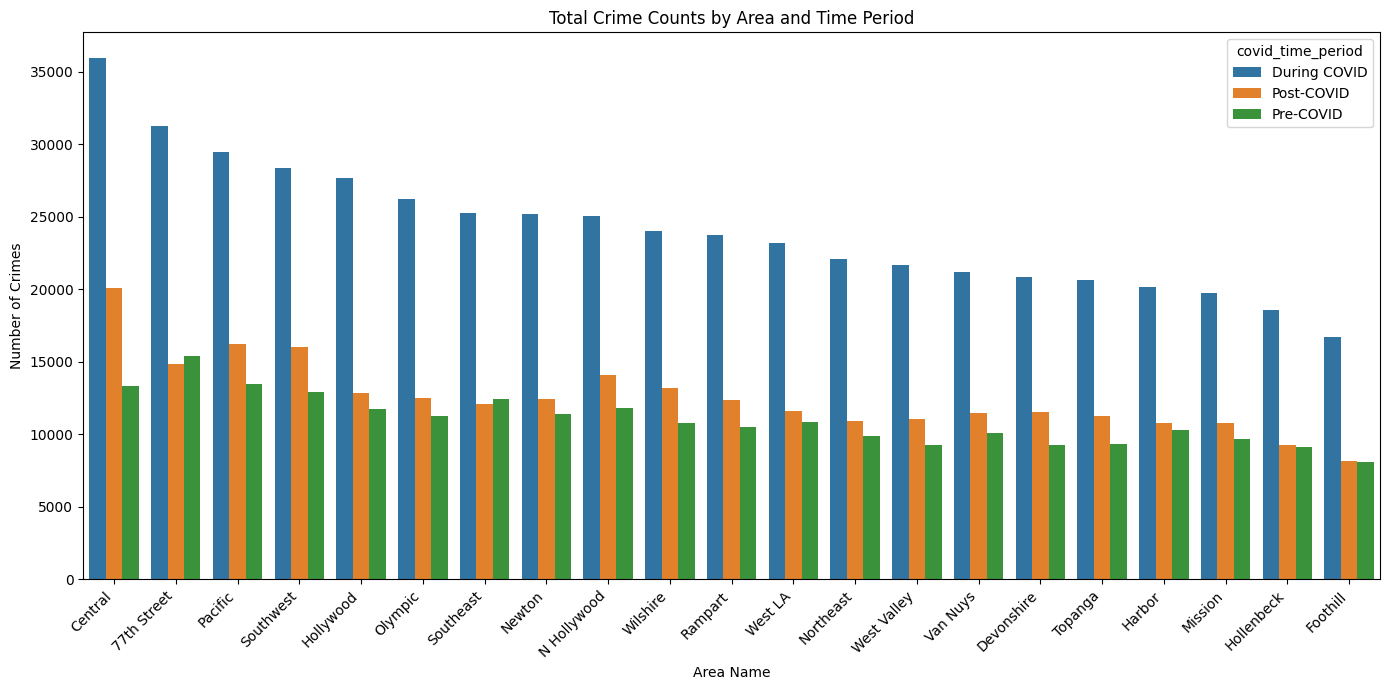

In [40]:
# plot it
plt.figure(figsize=(14, 7))
total_crimes_by_area_time_sorted = total_crimes_by_area_time.sort_values(by='total_crime_count', ascending=False)

sns.barplot(data=total_crimes_by_area_time_sorted, x = 'area_name', y = 'total_crime_count', hue ='covid_time_period')

plt.title('Total Crime Counts by Area and Time Period')
plt.xlabel('Area Name')
plt.ylabel('Number of Crimes')
plt.xticks(rotation = 45, ha='right')
plt.tight_layout()
plt.show()


#### Summary
- Overall Crime Trend: Generally, all areas experienced a higher crime count during COVID, followed by a decrease in the post-COVID period. However, the overall post-COVID crime count remained higher than the pre-COVID period, with the exception of 77th Street and Southeast, which showed lower counts than pre-COVID.

- Highest and Lowest Crime Areas & COVID Impact: Central had the highest crime count, while Foothill had the least. Notably, Central also experienced the largest surge in crime count when comparing the pre-COVID period to the during-COVID period, indicating it was the area most impacted by the increase.

- Return to Pre-COVID Levels: The post-COVID crime counts in Hollenbeck and Foothill are now approaching their pre-COVID levels, with the difference being minimal.

### Analysis of Dominant Crime Types Shifts in Each Area based on Count

In [38]:
crime_type_counts = crime_df_cleaned.groupby(['area_name', 'covid_time_period', 'simple_crm_desc']).size().reset_index(name='crime_count')

most_frequent_crimes = crime_type_counts.loc[crime_type_counts.groupby(['area_name', 'covid_time_period'])['crime_count'].idxmax()]

print("\nMost Frequent Crime Type by Area and Time Period:")
print(most_frequent_crimes)


Most Frequent Crime Type by Area and Time Period:
       area_name covid_time_period          simple_crm_desc  crime_count
9    77th Street      During COVID           simple_assault         5800
13   77th Street        Post-COVID         grand_theft_auto         2951
29   77th Street         Pre-COVID           simple_assault         2932
31       Central      During COVID  burg_theft_from_vehicle         7028
41       Central        Post-COVID  burg_theft_from_vehicle         3661
59       Central         Pre-COVID           simple_assault         2714
61    Devonshire      During COVID  burg_theft_from_vehicle         3383
75    Devonshire        Post-COVID              other_theft         2278
81    Devonshire         Pre-COVID  burg_theft_from_vehicle         1637
99      Foothill      During COVID           simple_assault         2644
103     Foothill        Post-COVID         grand_theft_auto         1511
119     Foothill         Pre-COVID           simple_assault         1436


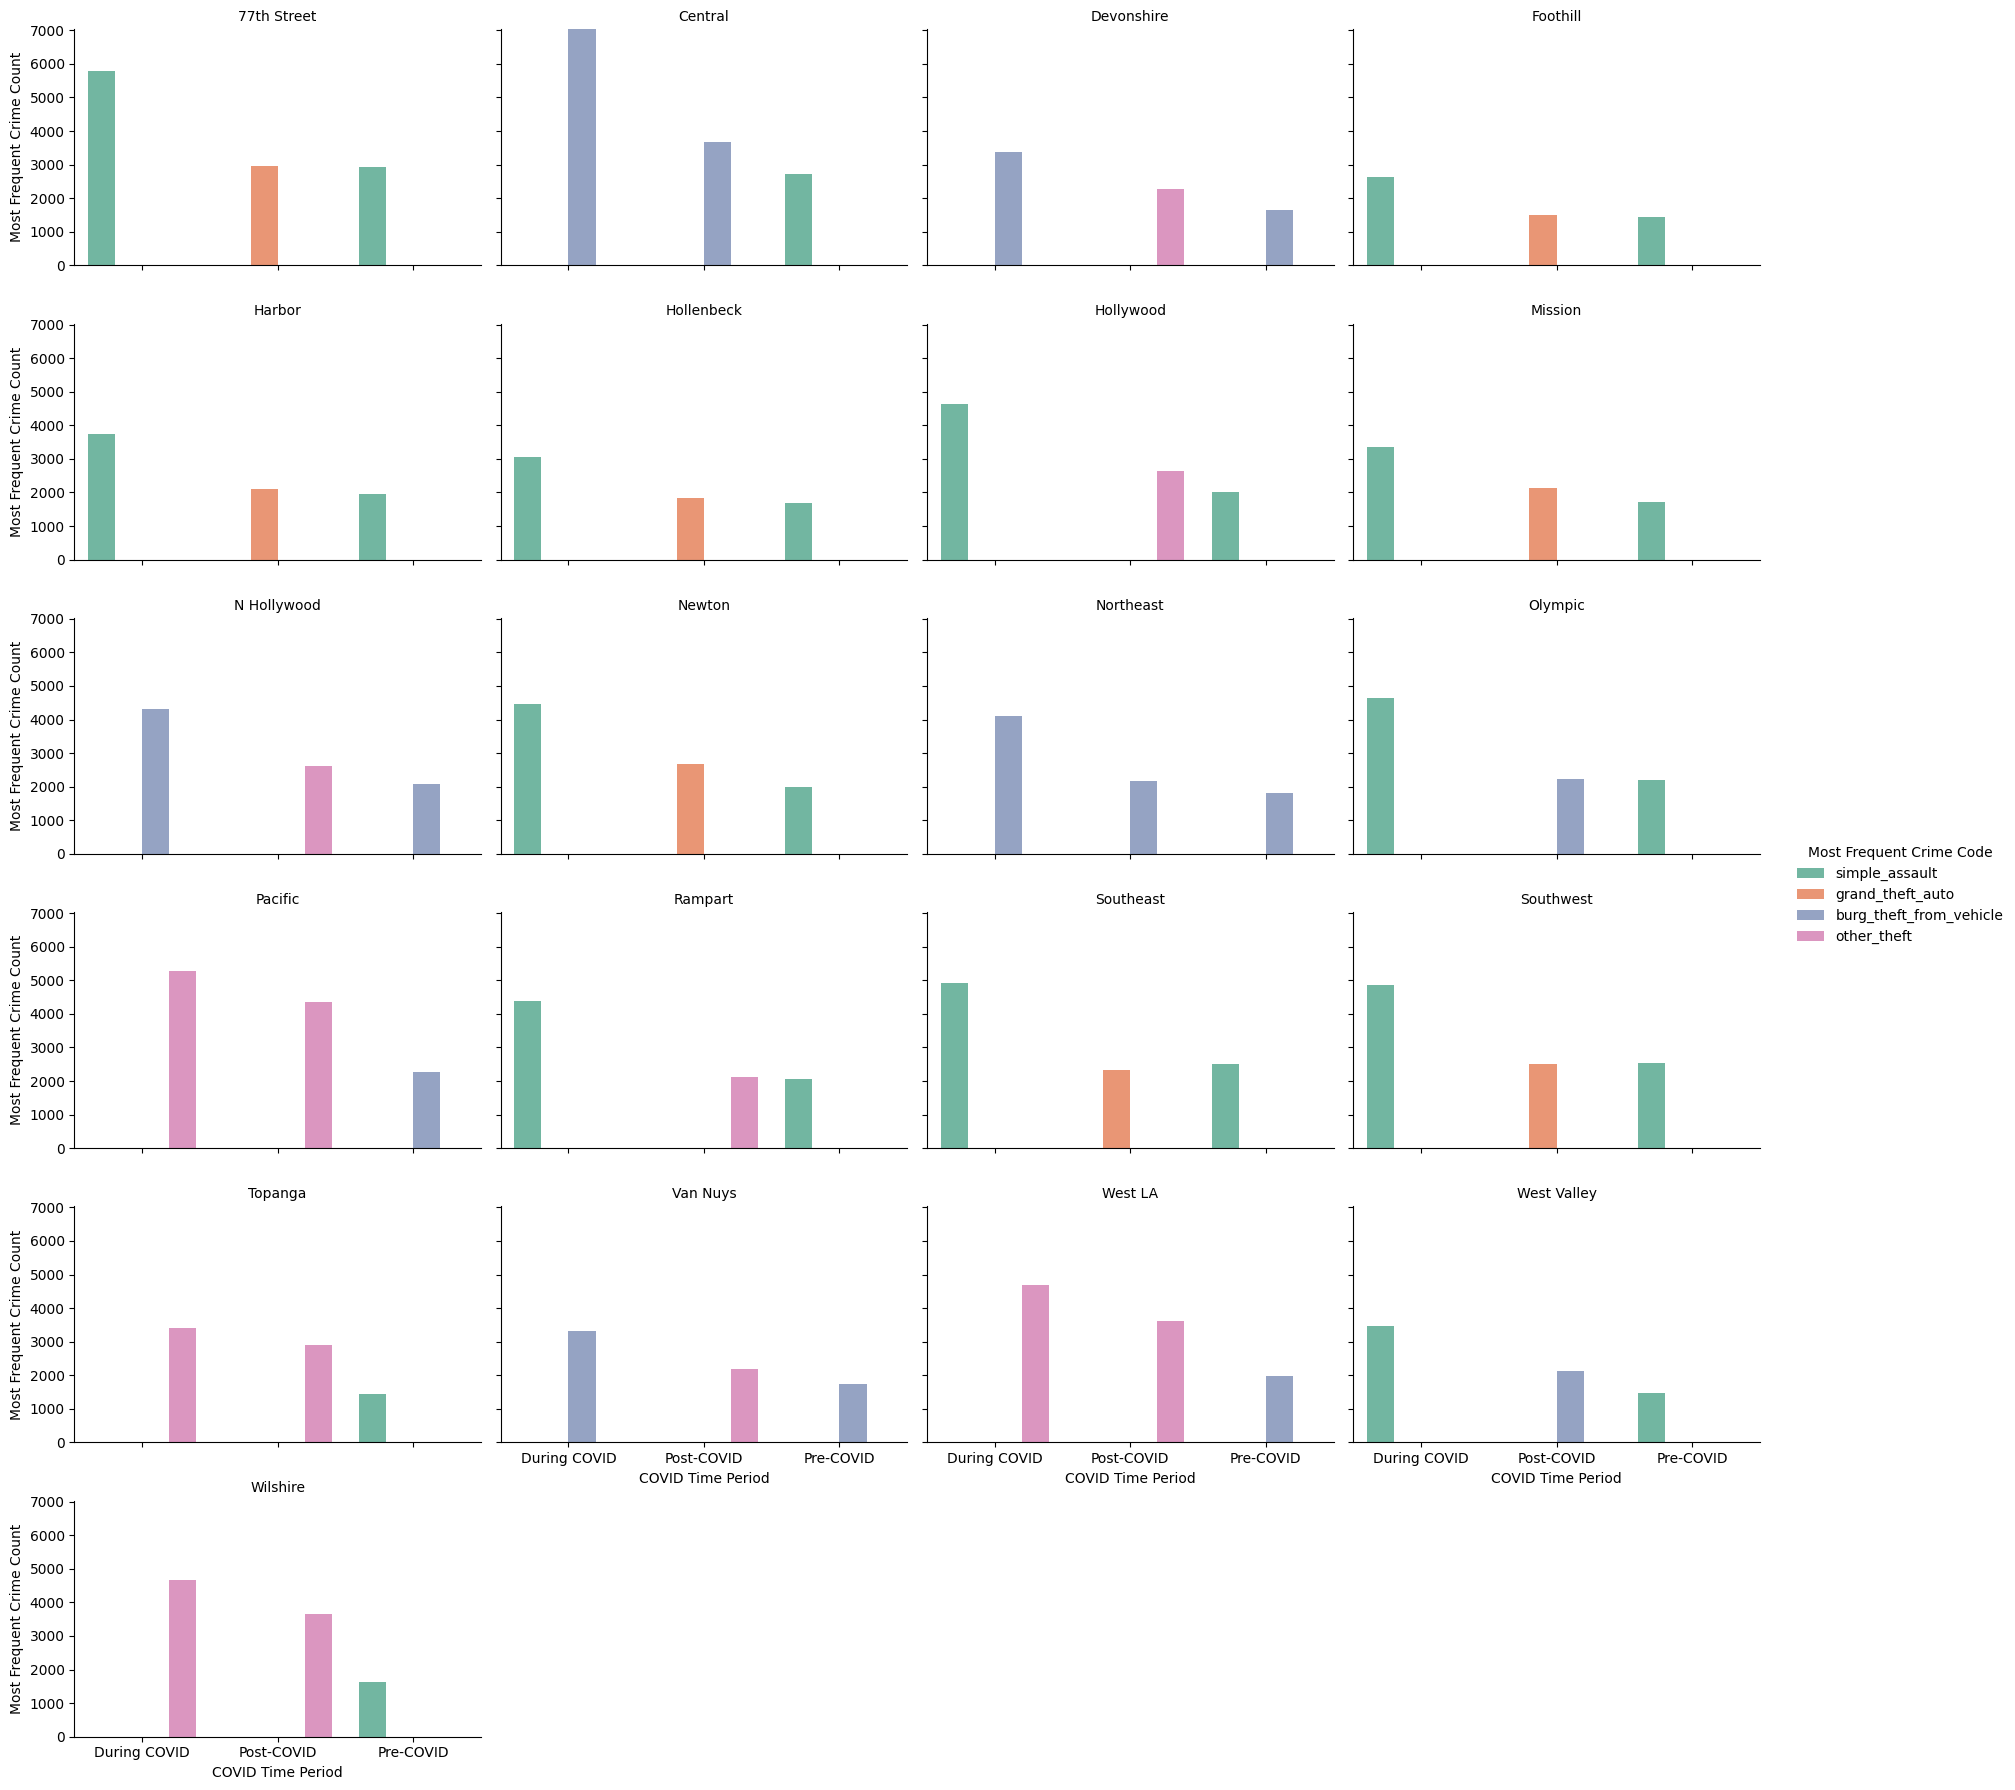

In [ ]:
# set a color palette with 6 distinct colors

palette = sns.color_palette("Set2", 6)

# plot

pivot_df = most_frequent_crimes.pivot_table(

index='covid_time_period',

columns='area_name',

values='crime_count',

aggfunc='first'

).reset_index()

melted_df = pd.melt(

pivot_df,

id_vars='covid_time_period',

var_name='area_name',

value_name='crime_count'

)
#get crime code

plot_df = pd.merge(

melted_df,

most_frequent_crimes[['area_name', 'covid_time_period', 'simple_crm_desc']].drop_duplicates(),

on=['area_name', 'covid_time_period'],

how='left'

)

plot_df['covid_time_period'] = pd.Categorical(

plot_df['covid_time_period'],

categories=sorted(plot_df['covid_time_period'].unique()),

ordered=True

)

# color mapping for crm_cd

plot_df['simple_crm_desc'] = plot_df['simple_crm_desc'].astype(str) # Make sure it's a string for coloring

unique_crm_cd = plot_df['simple_crm_desc'].unique()

crm_cd_palette = dict(zip(unique_crm_cd, palette[:len(unique_crm_cd)]))

g = sns.FacetGrid(

plot_df,

col='area_name',

col_wrap=4,

height=3,

aspect=1.5,

sharey=True,

)

g.map_dataframe(

sns.barplot,

x='covid_time_period',

y='crime_count',

hue='simple_crm_desc',

palette=crm_cd_palette,

dodge=True, hue_order=unique_crm_cd

)
global_max_y = plot_df['crime_count'].max()

g.set_axis_labels('COVID Time Period', 'Most Frequent Crime Count')

g.set(ylim=(0, global_max_y))

g.set_titles('{col_name}')

g.add_legend(title='Most Frequent Crime Code')

g.tight_layout()

plt.show()

#### Summary
- The crime trend varied across pre-, during-, and post-COVID periods. The dominant crime type in each period was, in order: simple assault, simple assault, and other theft.

- Notably, simple assault surged during the COVID period but decreased significantly in the post-COVID period. Conversely, grand theft auto became suddenly more common in the post-COVID period.

### Analysis Victim Demographics by Area based on count

In [96]:
victim_demographics_counts = crime_df_cleaned.groupby(['area_name', 'covid_time_period', 'vict_age', 'vict_sex', 'vict_descent']).size().reset_index(name='victim_count')
print("\nVictim Demographics Counts by Area and Time Period:")
print(victim_demographics_counts.head()) 


Victim Demographics Counts by Area and Time Period:
     area_name covid_time_period  vict_age vict_sex vict_descent  victim_count
0  77th Street      During COVID         0        F            B            68
1  77th Street      During COVID         0        F            H            51
2  77th Street      During COVID         0        F            O             3
3  77th Street      During COVID         0        F            W             7
4  77th Street      During COVID         0        F            X            17
